In [15]:
import seaborn as sns
df = sns.load_dataset('penguins')

# Molto utile per testare velocemente il parametro enable_categorical=True
print(df.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


In [16]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [18]:
# 1. Identifica automaticamente le colonne di tipo 'object'
cols_da_convertire = df.select_dtypes(include=['object']).columns

# 2. Convertile tutte in 'category'
for col in cols_da_convertire:
    df[col] = df[col].astype('category')

# Verifica il risultato
print(df.dtypes)

species              category
island               category
bill_length_mm        float64
bill_depth_mm         float64
flipper_length_mm     float64
body_mass_g           float64
sex                  category
dtype: object


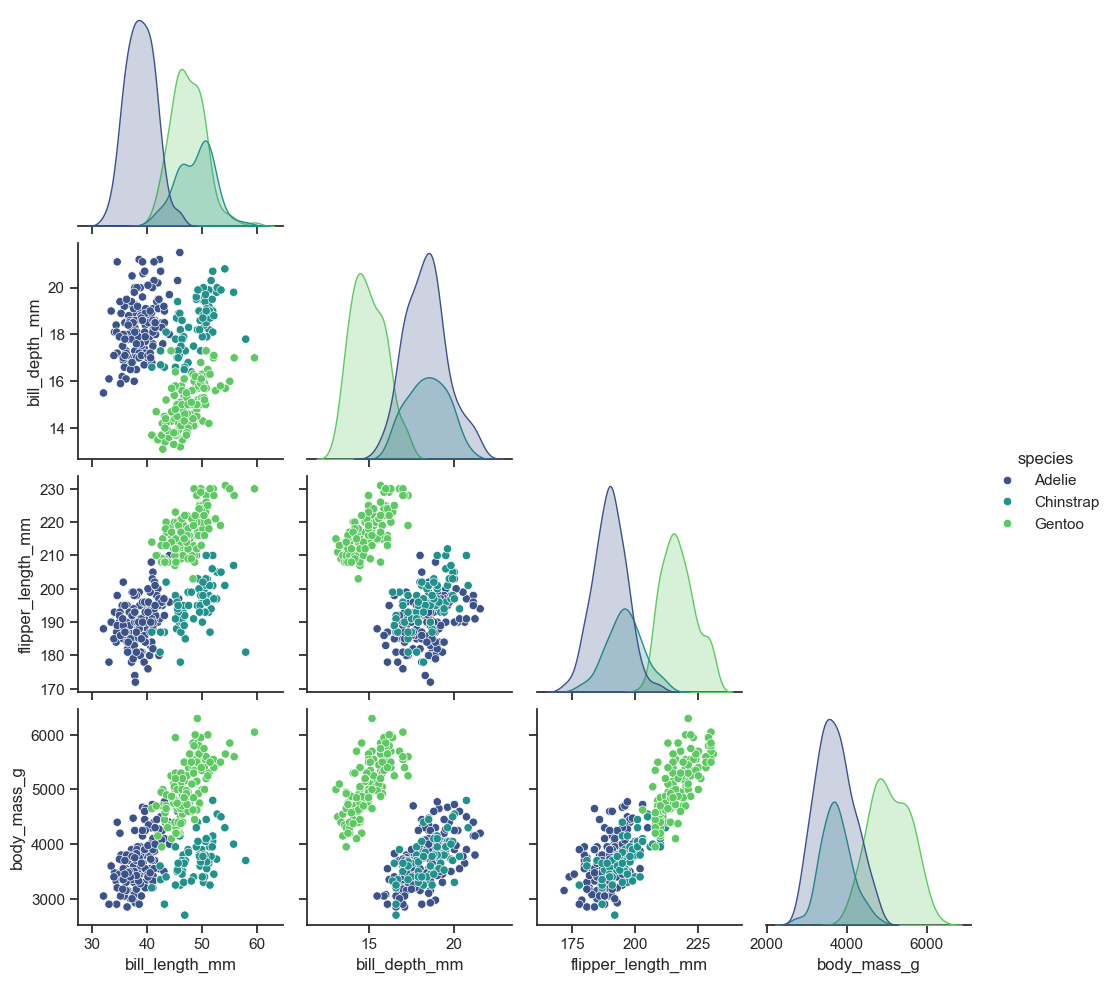

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Imposta lo stile
sns.set_theme(style="ticks")

# Genera il pairplot
# 'hue' usa la colonna categorica per distinguere i gruppi con i colori
sns.pairplot(df, hue='species', corner=True, palette='viridis')
plt.show()

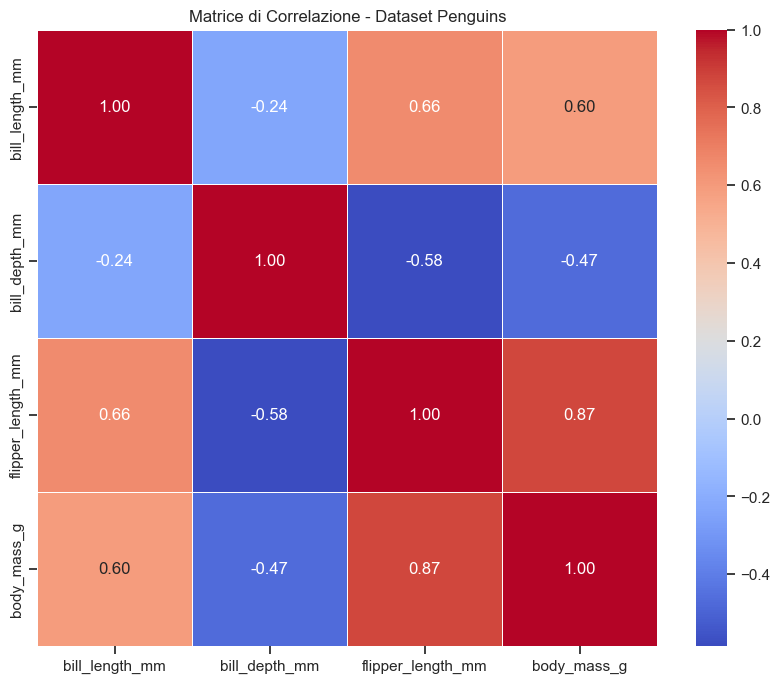

In [20]:
# 1. Calcola la matrice di correlazione solo per le colonne numeriche
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# 2. Crea la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matrice di Correlazione - Dataset Penguins')
plt.show()

In [21]:
# Creazione dei rapporti
df['bill_ratio'] = df['bill_length_mm'] / df['bill_depth_mm']
df['mass_flipper_ratio'] = df['body_mass_g'] / df['flipper_length_mm']

In [22]:
import pandas as pd

# Dividiamo il peso in 3 categorie basate sui percentili
df['body_mass_bin'] = pd.qcut(df['body_mass_g'], q=3, labels=['Small', 'Medium', 'Large'])
df['body_mass_bin'] = df['body_mass_bin'].astype('category')

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Definiamo le feature (X) e il target (y)
X = df.drop('species', axis=1)
y = df['species']

# Codifichiamo il target (da stringhe a numeri: 0, 1, 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y_encoded, 
    test_size=0.15, 
    random_state=41, 
    stratify=y_encoded # Fondamentale per mantenere l'equilibrio delle classi
)

print(f"Dimensioni Train: {X_train.shape}")
print(f"Dimensioni Test: {X_test.shape}")

Dimensioni Train: (292, 9)
Dimensioni Test: (52, 9)


In [25]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the XGBClassifier
# We use 'multi:softprob' because Penguins has 3 species (multiclass)
model = xgb.XGBClassifier(
    tree_method='hist',
    enable_categorical=True,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    # This automatically handles the missing values in 'sex' or measurements
    use_label_encoder=False 
)

# 2. Fit the model
# XGBoost will use the 'category' types from X_train automatically
model.fit(X_train, y_train)

# 3. Make predictions
y_pred = model.predict(X_test)

# 4. Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Model Accuracy: 98.08%

Classification Report:
              precision    recall  f1-score   support

      Adelie       0.96      1.00      0.98        23
   Chinstrap       1.00      0.90      0.95        10
      Gentoo       1.00      1.00      1.00        19

    accuracy                           0.98        52
   macro avg       0.99      0.97      0.98        52
weighted avg       0.98      0.98      0.98        52



c:\Users\mbagn\anaconda3\envs\pytorch\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:52:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


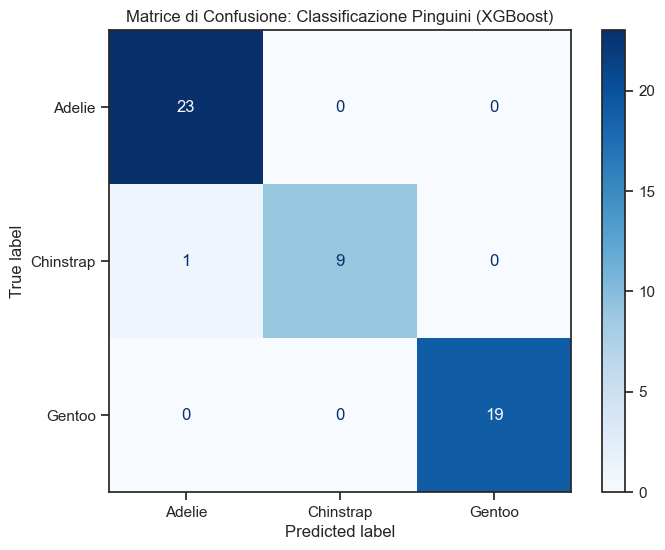

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Calcoliamo la matrice di confusione
# y_test sono i valori reali, y_pred sono quelli previsti dal modello
cm = confusion_matrix(y_test, y_pred)

# 2. Creiamo la visualizzazione
# Usiamo le.classes_ per mostrare i nomi reali delle specie (Adelie, ecc.) invece di 0, 1, 2
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

# 3. Plot con stile
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Matrice di Confusione: Classificazione Pinguini (XGBoost)')
plt.grid(False) # Toglie la griglia che a volte disturba la lettura
plt.show()